In [58]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math




def save_graph(G, n, a):
	# nx.write_graphml(G, f"./graphs/G_n={n}_a={a}.graphml")
	nx.write_graph6(G, f"./graphs/G_n={n}_a={a}.g6")

def save_graphs(graph_list):
	for G, n, a in graph_list:
		save_graph(G, n, a)

def display_graphs(graphs, figsize=(15, 15)):
	def axes_division(x):
		factor1 = 1
		for i in range(1, int(math.sqrt(x))+1):
			if x % i == 0:
				factor1 = i
		return int(factor1), int(x/factor1)
	
	rows, cols = axes_division(len(graphs))
	fig, axes = plt.subplots(rows, cols, figsize=figsize)
	# fix: flatten the plot axes
	axes = np.array(axes).flatten()
	
	for i, (graph_touple, ax) in enumerate(zip(graphs, axes)):
		G, n, a = graph_touple
		
		pos = nx.spring_layout(G, seed=100)
		# pos = nx.spring_layout(G, k=0.8, iterations=200)  
		nx.draw(G, pos, ax=ax, with_labels=True, node_size=20, font_size=10, node_color=['red' if G.nodes[n].get("infected") else 'lightgray' for n in G])
		ax.set_title(f"Graph C({n}, {a})")
		ax.set_aspect('equal')

	plt.tight_layout()
	plt.show()

def generate_graphs(n):
	n_half = int(n/2)
	graphs = []
	
	def add_candidate_graph(H, a):
		nonlocal graphs
		for (G_i, _, _) in graphs:
			if nx.is_isomorphic(G_i, H):
				return
		graphs.append((H, n, a))
	
	for a in range(n_half):
		gcd = np.gcd(a, n_half)
		condition = (1 <= a < n_half and gcd == 1)
		
		if condition:
			g = nx.circulant_graph(n, [a, -a, n_half])
			add_candidate_graph(g, a)
			# print(f"a={a} n={n}")
	
	print(f"number of graphs for n={n} :", len(graphs))
	return graphs

def is_infectable(G, node):
	node_N = list(nx.all_neighbors(G, node))
	if len(node_N) < 2:
		return False
	
	infected_N_counter = sum(1 for i_neighbor in node_N 
							 if G.nodes[i_neighbor].get("infected"))
	return infected_N_counter >= 2

def fully_endemic(G):
	max_itter_number = len(G.nodes)
	infected_nodes = [n for n in G.nodes if G.nodes[n].get("infected")]
	healthy_nodes = [n for n in G.nodes if not G.nodes[n].get("infected")]

	itter_number = 0
	while len(healthy_nodes) > 0:
		for node in healthy_nodes:
			if is_infectable(node):
				G.nodes[node]["infected"] = True
				infected_nodes.append(node)
				healthy_nodes.remove(node)

		itter_number+=1
		# print("itter number=", itter_number, "infected_nodes:", infected_nodes, "healthy_nodes", healthy_nodes)
		if itter_number > max_itter_number:
			break
	
	return infected_nodes, healthy_nodes

def infection_spread(G, n, a):
	graph_stages = [G.copy()]
	infected_nodes = [u for u in G.nodes if G.nodes[u].get("infected")]
	healthy_nodes = [u for u in G.nodes if not G.nodes[u].get("infected")]

	itter_number = 0
	max_iters = len(G.nodes)

	while healthy_nodes:
		changed = False

		for node in healthy_nodes[:]:
			if is_infectable(G, node):
				G.nodes[node]["infected"] = True
				infected_nodes.append(node)
				healthy_nodes.remove(node)
				graph_stages.append(G.copy())
				changed = True

		itter_number += 1
		if itter_number > max_iters or not changed:
			break

	return [(H, n, a) for H in graph_stages], infected_nodes, healthy_nodes

def show_graph_infection(H):
	print("C=", end="")
	for j in H.nodes:
		if H.nodes[j].get("infected"):
			print(1, end="")
		else:
			print(0, end="")
	print()

def infection_graph_permuation(vertex_list, infection_number, z=0):
	# Base case: no more infections to place
	if infection_number == 0:
		yield vertex_list
		return

	# Try placing the next infection at any allowed index
	for i in range(z, len(vertex_list)):
		if vertex_list[i] == 0:
			new_list = vertex_list[:]  # copy
			new_list[i] = 1
			yield from infection_graph_permuation(new_list, infection_number - 1, i + 1)

def infect_graph(G, infection_mask):
	H = G.copy()
	for i, e in enumerate(infection_mask):
		H.nodes[i]["infected"] = bool(e)
	return H

def generate_graphs2(n):
	n_half = int(n/2)
	graphs = []
	
	def add_candidate_graph(H, a):
		nonlocal graphs
		for (G_i, n_i, a_i) in graphs:
			if nx.is_isomorphic(G_i, H):
				print(f"n={n_i} a={a_i} is isomorpic")
				return
		graphs.append((H, n, a))
	
	for a in range(n_half):
		gcd = np.gcd(a, n_half)
		condition = (1 <= a < n_half and gcd == 1)
		
		if condition:
			g = nx.circulant_graph(n, [a, -a, n_half])
			add_candidate_graph(g, a)
	
	print(f"number of graphs for n={n} :", len(graphs))
	return graphs

	

number of graphs for n=7 : 1
[1, 1, 1, 1, 0, 0, 0] I/H:  1.0
i_s 4


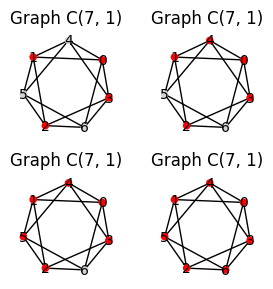

[1, 1, 1, 0, 1, 0, 0] I/H:  1.0
i_s 4


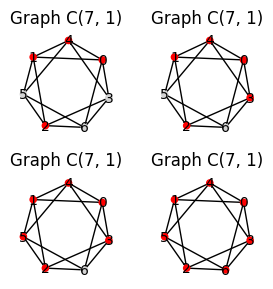

[1, 1, 1, 0, 0, 1, 0] I/H:  1.0
i_s 4


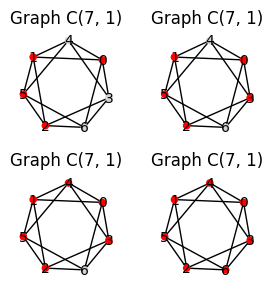

[1, 1, 1, 0, 0, 0, 1] I/H:  1.0
i_s 4


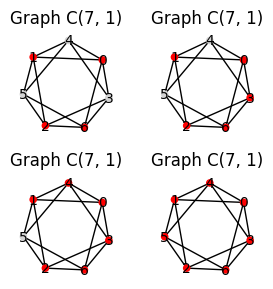

[1, 1, 0, 1, 1, 0, 0] I/H:  1.0
i_s 4


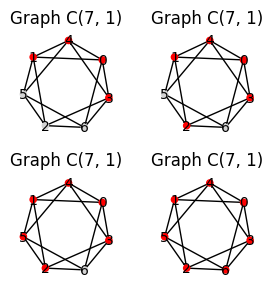

[1, 1, 0, 1, 0, 1, 0] I/H:  1.0
i_s 4


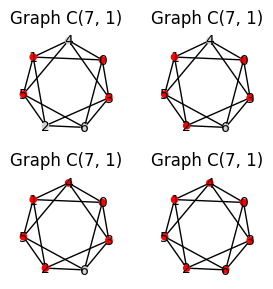

[1, 1, 0, 1, 0, 0, 1] I/H:  1.0
i_s 4


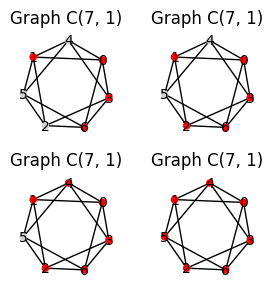

[1, 1, 0, 0, 1, 1, 0] I/H:  1.0
i_s 4


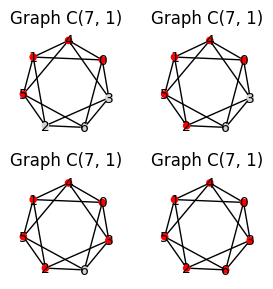

[1, 1, 0, 0, 1, 0, 1] I/H:  1.0
i_s 4


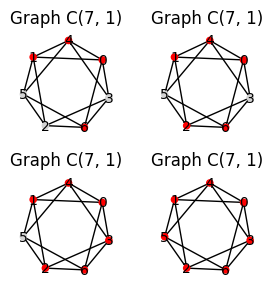

[1, 1, 0, 0, 0, 1, 1] I/H:  1.0
i_s 4


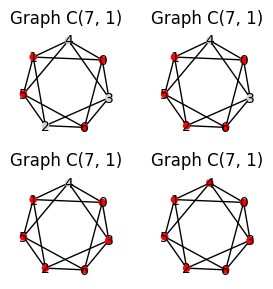

[1, 0, 1, 1, 1, 0, 0] I/H:  1.0
i_s 4


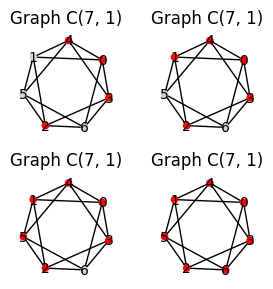

[1, 0, 1, 1, 0, 1, 0] I/H:  1.0
i_s 4


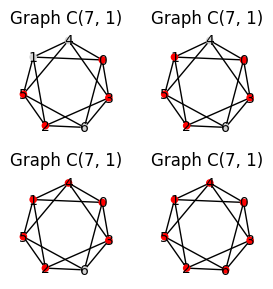

[1, 0, 1, 1, 0, 0, 1] I/H:  1.0
i_s 4


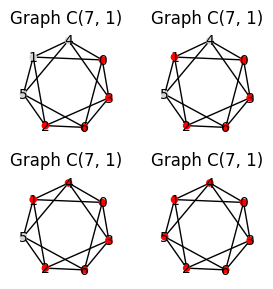

[1, 0, 1, 0, 1, 1, 0] I/H:  1.0
i_s 4


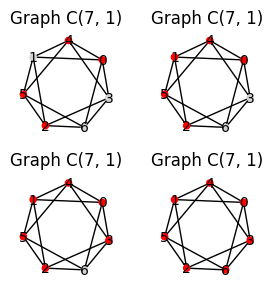

[1, 0, 1, 0, 1, 0, 1] I/H:  1.0
i_s 4


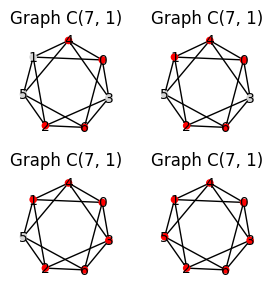

[1, 0, 1, 0, 0, 1, 1] I/H:  1.0
i_s 4


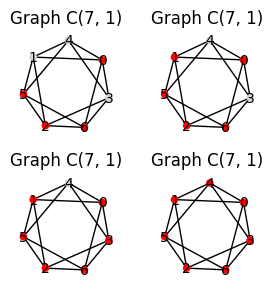

[1, 0, 0, 1, 1, 1, 0] I/H:  1.0
i_s 4


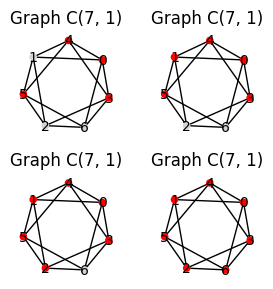

[1, 0, 0, 1, 1, 0, 1] I/H:  1.0
i_s 4


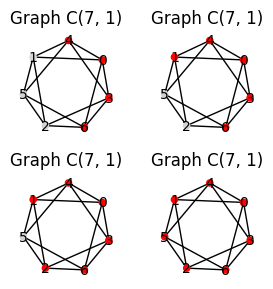

[1, 0, 0, 1, 0, 1, 1] I/H:  1.0
i_s 4


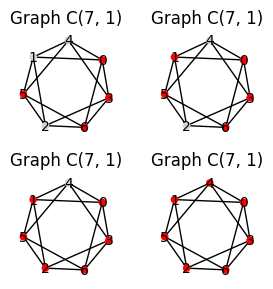

[1, 0, 0, 0, 1, 1, 1] I/H:  1.0
i_s 4


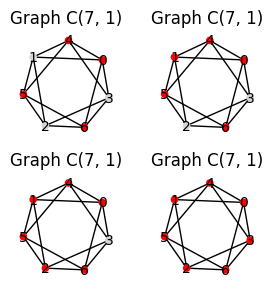

[0, 1, 1, 1, 1, 0, 0] I/H:  1.0
i_s 4


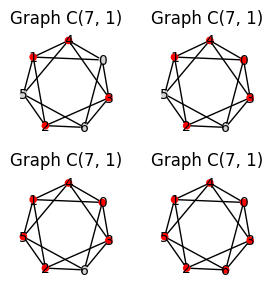

[0, 1, 1, 1, 0, 1, 0] I/H:  1.0
i_s 4


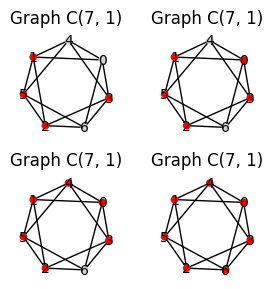

[0, 1, 1, 1, 0, 0, 1] I/H:  1.0
i_s 4


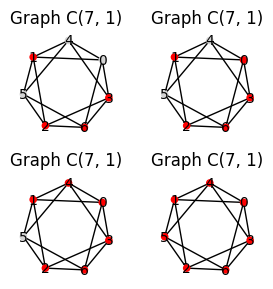

[0, 1, 1, 0, 1, 1, 0] I/H:  1.0
i_s 4


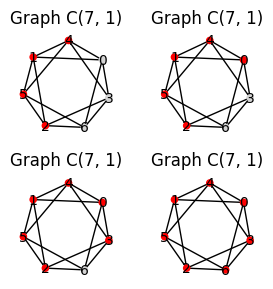

[0, 1, 1, 0, 1, 0, 1] I/H:  1.0
i_s 4


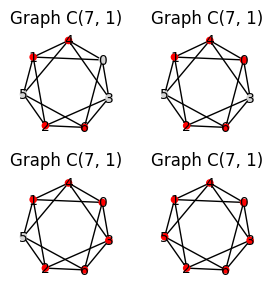

[0, 1, 1, 0, 0, 1, 1] I/H:  1.0
i_s 4


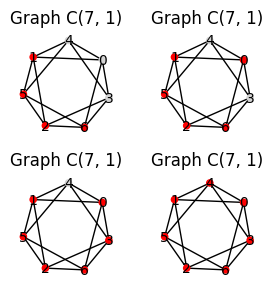

[0, 1, 0, 1, 1, 1, 0] I/H:  1.0
i_s 4


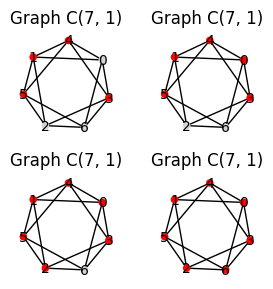

[0, 1, 0, 1, 1, 0, 1] I/H:  1.0
i_s 4


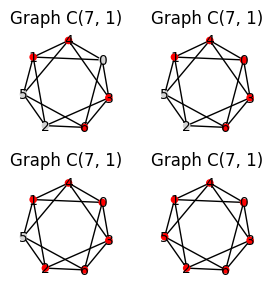

[0, 1, 0, 1, 0, 1, 1] I/H:  1.0
i_s 4


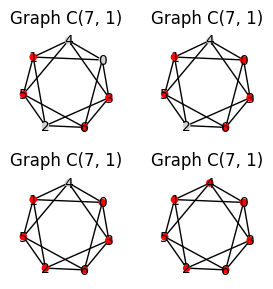

[0, 1, 0, 0, 1, 1, 1] I/H:  1.0
i_s 4


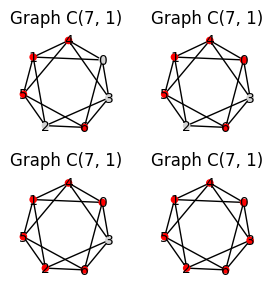

[0, 0, 1, 1, 1, 1, 0] I/H:  1.0
i_s 4


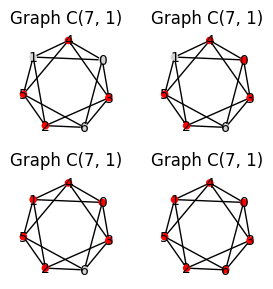

[0, 0, 1, 1, 1, 0, 1] I/H:  1.0
i_s 4


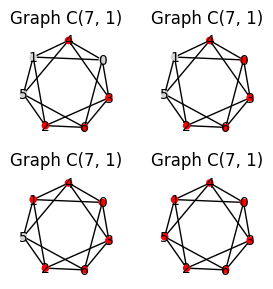

[0, 0, 1, 1, 0, 1, 1] I/H:  1.0
i_s 4


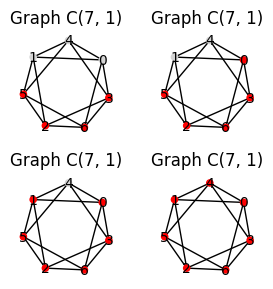

[0, 0, 1, 0, 1, 1, 1] I/H:  1.0
i_s 4


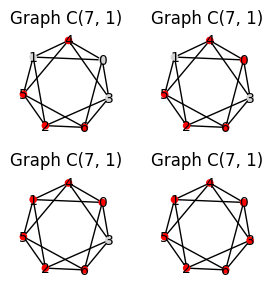

[0, 0, 0, 1, 1, 1, 1] I/H:  1.0
i_s 4


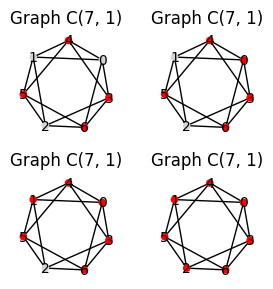

In [ ]:
N = 7
k = 4
G, n, a = generate_graphs(N)[0]


graph_infection_permutation_list = []

for infection in infection_graph_permuation([0] * N, k):
	print(infection, end=" ")
	H = infect_graph(G, infection)   # now returns a real graph
	graph_infection_permutation_list.append((H, n, a))
	i_s, i_n, h_n = infection_spread(H, n, a)
	andemic = len(i_n)/len(H.nodes)
	print("I/H: ", andemic)
	print("i_s", len(i_s))

	if andemic:
		display_graphs(i_s, figsize=(3, 3))
		break

# display_graphs(graph_infection_permutation_list)


number of graphs for n=8 : 1
infected node:  4
infected node:  7
infected node:  5
infected node:  6


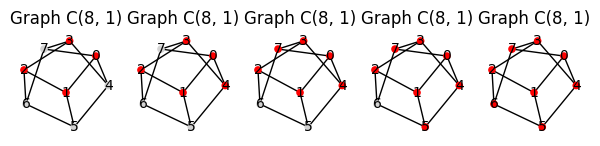

In [55]:

G, n, a = generate_graphs(8)[0]

# A = nx.adjacency_matrix(G)

# print(A.toarray())

# # fully_endemic(G)

# def adjacency_list(G):
# 	ajd_list = []
# 	for i in G.nodes:
# 		ajd_list.append(list(nx.all_neighbors(G, i)))
# 	return ajd_list

# print(adjacency_list(G))

G.nodes[0]["infected"] = 1
G.nodes[1]["infected"] = 1
G.nodes[2]["infected"] = 1
G.nodes[3]["infected"] = 1

infection_stages, _, _ = infection_spread(G, n, a)
display_graphs(infection_stages, figsize=(6, 6))


In [ ]:




graphs = generate_graphs(8)
G, n, a = graphs[0]

infect_graph(G, 4)


In [ ]:
search_space = 36
graphs = []

for i in range(4, search_space+1, 2):
    n_graph_list = generate_graphs(i)
    graphs += n_graph_list

print(len(graphs))

display_graphs(graphs)
save_graphs(graphs)


In [ ]:
import random

G, n, a = generate_graphs(22)[1]
# fully_endemic(G)

G.nodes[0]["infected"] = 1

print(G.nodes)

def build_tree(G, start_vertex=0):
    tree_graph = nx.Graph()
    tree_graph.add_nodes_from(G.nodes)
    current_vertex = start_vertex

    visited_vertexes = set()
    vertexes_2_visit = set([start_vertex])
        
    while True:
        current_vertex = vertexes_2_visit.pop()
        visited_vertexes.add(current_vertex)

        neighbor_list = list(nx.all_neighbors(G, current_vertex))
        random2neighbors = set(random.sample(i_neighbors_list, k=min(len(i_neighbors_list), 2)))

        vertexes_2_visit |= random2neighbors

        print("visited_vertexes:", visited_vertexes, " vertexes_2_visit:", vertexes_2_visit)

        # iterate over a snapshot
        for vertex_i in list(vertexes_2_visit):
            G.add_edge(current_vertex, vertex_i)
            visited_vertexes.add(vertex_i)

            i_neighbors = visited_vertexes - set(nx.all_neighbors(G, current_vertex))

            # sample from a list, not a set
            i_neighbors_list = list(i_neighbors)
            random2neighbors = set(random.sample(i_neighbors_list, k=min(len(i_neighbors_list), 2)))

            vertexes_2_visit |= random2neighbors

            current_vertex = vertexes_2_visit.pop()
            print(current_vertex)
            if len(visited_vertexes) >= len(G.nodes):
                break

build_tree(G)


In [ ]:
import random

s = {1, 2, 3, 4}

t = {1}

neighbors = [1, 2, 3]

t | set(random.sample(neighbors, k=min(len(neighbors), 2)))


visited_vertexes = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21}
vertexes_2_visit = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21}

vertexes_2_visit.diffrence(visited_vertexes)


In [ ]:
G = nx.circulant_graph(10, [3, -3, 5])



display_graphs([(G, 10, 3)], figsize=(4, 4))


# graphs = generate_graphs(8)
# G, n, a = graphs[0]



graphs = generate_graphs2(10)
display_graphs(graphs, figsize=(4, 4))



nx.is_isomorphic(graphs[0][0], graphs[2][0])


In [ ]:
graphs = generate_graphs2(16)
display_graphs(graphs, figsize=(4, 4))